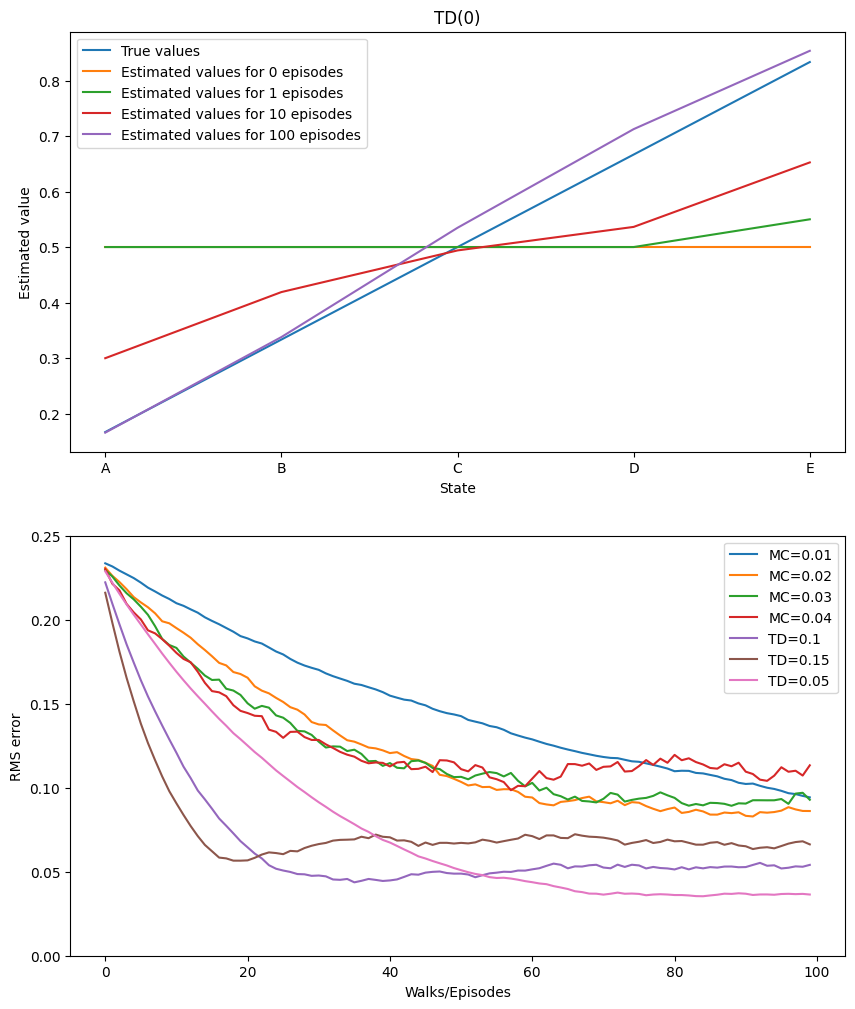

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#intialize mdp
mdp=np.zeros((7,7))
mdp[5,6]=1


#take action
def step():
    if np.random.binomial(1,0.5)==1:
        action=1
    else:
        action=-1
    return action


def td_0(step_size,v):
    state=3
    #generate episode
    while(True):
        if state==0 or state==6:
            break
        action=step()
        new_state=state+action
        reward=mdp[state,new_state]
        v[state]+=step_size*(reward+v[new_state]-v[state])
        state=new_state
    return v


def every_visit_mc(step_size,v):
    state=3
    reward=None
    episode_values=[]
    states=[]
    #generate episode
    while(True):
        if state==0 or state==6:
            episode_values.append((state,None,reward))
            states.append(state)
            break
        action=step()
        new_state=state+action
        episode_values.append((state,action,reward))
        states.append(state)
        reward=mdp[state,new_state]
        state=new_state

    #calculate returns for each state
    gt=0
    for i in range(len(episode_values)-2,-1,-1):
        state=episode_values[i][0]
        reward=episode_values[i+1][2]
        gt=reward+gt
        v[state]+=step_size*(gt-v[state])
    return v

#values of each state for different episodes
fig,ax=plt.subplots(2,1,figsize=(10,12))
true_values=[i/6 for i in range(1,6)]
ax1=ax[0]
ax1.plot(range(1,6),true_values,label='True values')
for i in [0,1,10,100]:
    v={}
    for j in range(6):
        v[j]=0.5
    v[0],v[6]=0,0
    for episodes in range(i):
        v=td_0(0.1,v)
    estimated_values=[v[i] for i in range(1,6)]
    ax1.plot(range(1,6),estimated_values,label='Estimated values for '+str(i)+' episodes')
ax1.legend()
ax1.set_xlabel('State')
ax1.set_ylabel('Estimated value')
ax1.set_title('TD(0)')
ax1.set_xticks(range(1,6))
ax1.set_xticklabels(['A','B','C','D','E'])


num_episodes=100
num_runs=100

ax2=ax[1]

#monte carlo runs
for alpha in [0.01,0.02,0.03,0.04]:
    average_v=np.zeros(100)
    for i in range(num_runs):
        v={}
        for j in range(1,6):
            v[j]=0.5
        for j in range(num_episodes):
            v=every_visit_mc(alpha,v)
            estimated_values=[v[i] for i in range(1,6)]
            rms=np.sqrt(np.mean(np.square(np.array(estimated_values)-np.array(true_values))))
            average_v[j]+=rms
    average_v=average_v/num_runs
    ax2.plot(range(100),average_v,label='MC='+str(alpha))


#td runs
for alpha in [0.1,0.15,0.05]:
    average_v=np.zeros(100)
    for i in range(num_runs):
        v={}
        for j in range(7):
            v[j]=0.5
        v[0],v[6]=0,0
        for j in range(num_episodes):
            v=td_0(alpha,v)
            estimated_values=[v[i] for i in range(1,6)]
            rms=np.sqrt(np.mean(np.square(np.array(estimated_values)-np.array(true_values))))
            average_v[j]+=rms
    average_v=average_v/num_runs
    ax2.plot(range(100),average_v,label='TD='+str(alpha))

#td vs mc graph
ax2.legend()
ax2.set_xlabel('Walks/Episodes')
ax2.set_ylabel('RMS error')
ax2.set_ylim(0,0.25)
plt.show()





